# AP 155 Lab Exercise
---
## Exercise 7: Root Finding

_Instructions_: 
- **Report figure:** (See Problem) Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).
- **Report discussion:**
    - Explain the report figure.
    - What are the advantages and disadvantages of the root-finding methods?
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Delos Santos, Mico
- _Student No._: 2024-35117
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

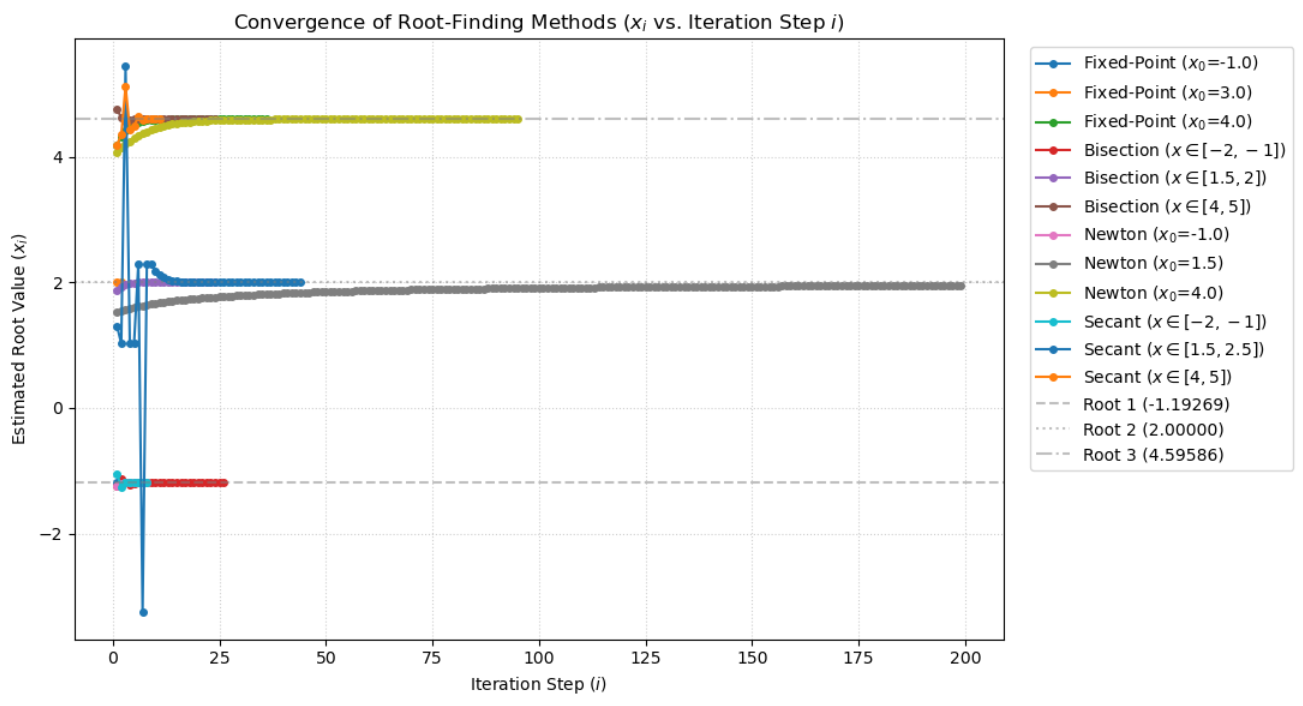

### Report discussion

The figure above is the plot the convergence of the values towards the root of $f(x)$. This includes the overlay convergence curves and the plot $x_i$ vs. $i$ for each of the four methods. I'll compare these methods right away, $Newton's > Secant > Bisection > Fixed-Point$. 

Fixed-point is the worst method among the group because I have to divide the region into three ($g_1(x), g_2(x), g_3(x)$), compare to the other methods in which the I used $f(x)$ right away. For Bisection method, it's hard to get the function's double roots. Similar to Fixed-point, both methods show slow linear convergence, and these methods used no derivatives.
The secant method resolve the disadvantage of the bisection method, being able to get the double roots of the function, and it also does not require a derivative. Its only problem is that it requires two initial guesses and bounced back all over the place before it stabilized. Lastly, Newton's method is the best method being the fastest one to converge, only requiring one initial guess, and works with roots multiplicity. With its derivative, I can be assured that the value I will be getting is correct as long as $f'(x_0) \neq 0$ as it will diverge.

### Other comments
- So far, which among the Gezerlis section will be the most useful? Will it be depending on the physics path?


---
## Section 2: Code

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1: Root Finding


Implement root finders *manually* to find the roots of an arbitrary function

1. fixed-point method (relaxation, needs an initial guess)
2. bisection method (bracketing, needs two bounds)
3. newton's method (known derivative, needs an initial guess)
4. secant method (approximate derivative, needs two initial guesses)

Consider the function

$$
f(x) = -x^5 + 4x^4 - 4x^3 + x^2 e^x - 2x^2 -4xe^x + 8x + 4e^x -8
$$

5. Plot the function from x=-2 to x=5. You may want to "enlarge" the plot by rescaling/"cropping" the y-axis. You should be able to estimate where the roots are approximately
   
6. Find the roots of $f(x)$ by implementing the four methods shown.

7. Report Figure: Plot the convergence of the values towards the root of $f(x)$. That is, plot $x_i$ vs. $i$ for each of the four methods ($x_i$ is the output of the method on the $i$th step). Overlay the convergence curves on a single plot and check the convergence. You may have more than four curves; for instance, you could have used newton's method twice for two different guesses. Make sure to label your curves (method + initial guesses).

In [165]:
#1 fixed-point method
#f(x) = -x**5 + 4*x**4 - 4*x**3 + (x**2)*exp(x) - 2*x**2 - (4*x)*exp(x) + 8*x + 4*exp(x) - 8
#by relaxation f(x) -> g_i(x) by factoring f(x) and solving for x's.
def g_1(x):
    val = exp(x) - 2
    if val < 0:
        return -(-val)**(1/3)
    return val**(1/3)

def g_2(x):
    return 2.0

def g_3(x):
    return log(x**3 + 2)

def fixedpoint(g, x_0, kmax=200, tol=1.e-8):
    for k in range (1, kmax):
        x_f = g(x_0)
        
        x_diff = x_f - x_0
        print("{0:2d} {1:1.16f} {2:1.16f}".format(k, x_f, x_diff))

        if abs(x_diff/x_f) < tol:
            break
            
        x_0 = x_f
    else:
        x_f = None
        
    return x_f

if __name__ == '__main__':
    runs = [(g_1, -1.0), (g_2, 3.0), (g_3, 4.0)]

    for g_func, xold in runs:
        x = fixedpoint(g_func, xold)
        print(x)

 1 -1.1773820537384183 -0.1773820537384183
 2 -1.1915883430411991 -0.0142062893027808
 3 -1.1926076939341195 -0.0010193508929204
 4 -1.1926802141784245 -0.0000725202443050
 5 -1.1926853703743210 -0.0000051561958965
 6 -1.1926857369643775 -0.0000003665900565
 7 -1.1926857630277501 -0.0000000260633726
 8 -1.1926857648807716 -0.0000000018530215
-1.1926857648807716
 1 2.0000000000000000 -1.0000000000000000
 2 2.0000000000000000 0.0000000000000000
2.0
 1 4.1896547420264252 0.1896547420264252
 2 4.3246871561049192 0.1350324140784940
 3 4.4174453405637628 0.0927581844588437
 4 4.4796211123007863 0.0621757717370235
 5 4.5206202932005182 0.0409991808997319
 6 4.5473655464365832 0.0267452532360650
 7 4.5646903245247215 0.0173247780881383
 8 4.5758618958159225 0.0111715712912011
 9 4.5830446069104216 0.0071827110944991
10 4.5876540102835808 0.0046094033731592
11 4.5906084581295490 0.0029544478459682
12 4.5925006783324349 0.0018922202028859
13 4.5937119782182956 0.0012112998858607
14 4.59448714264

In [171]:
#2 bisection method
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + x**2*exp(x) - 2*x**2 - 4*x*exp(x) + 8*x + 4*exp(x) - 8

def bisection_method(f, x_0, x_1, kmax=200, tol=1.e-8):
    f_0 = f(x_0)
    for k in range(1, kmax):
        x_2 = (x_0 + x_1) / 2
        f_2 = f(x_2)

        if f_0 * f_2 < 0:
                 x_1 = x_2
        else:
            x_0, f_0 = x_2, f_2
        
        x_2new = (x_0 + x_1) / 2
        x_diff = abs(x_2new - x_2)
        rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
        print(rowf.format(k, x_2new, x_diff, abs(f(x_2new))))

        if abs(x_diff/x_2new) < tol:
            break
    else:
        x_2new = None

    return x_2new

if __name__ == '__main__':
    root = bisection_method(f,-2.0, -1.0)
    print(root); print("")
    root = bisection_method(f, 1.5, 2.0)
    print(root)
    root = bisection_method(f, 4.0, 5.0)
    print(root)

 1 -1.2500000000000000 0.2500000000000000 2.5310897293357577
 2 -1.1250000000000000 0.1250000000000000 2.4562442152504893
 3 -1.1875000000000000 0.0625000000000000 0.2078431100025773
 4 -1.2187500000000000 0.0312500000000000 1.0968675370279009
 5 -1.2031250000000000 0.0156250000000000 0.4287620725555499
 6 -1.1953125000000000 0.0078125000000000 0.1065760130030107
 7 -1.1914062500000000 0.0039062500000000 0.0515977058665031
 8 -1.1933593750000000 0.0019531250000000 0.0272472776810293
 9 -1.1923828125000000 0.0009765625000000 0.0122355783610510
10 -1.1928710937500000 0.0004882812500000 0.0074907455134330
11 -1.1926269531250000 0.0002441406250000 0.0023761908249833
12 -1.1927490234375000 0.0001220703125000 0.0025563335395287
13 -1.1926879882812500 0.0000610351562500 0.0000898354316519
14 -1.1926574707031250 0.0000305175781250 0.0011432366748814
15 -1.1926727294921875 0.0000152587890625 0.0005267153665649
16 -1.1926803588867188 0.0000076293945312 0.0002184436537451
17 -1.1926841735839844 0

In [141]:
#3 Newton's method
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + x**2*exp(x) - 2*x**2 - 4*x*exp(x) + 8*x + 4*exp(x) - 8

def df(x):
    return -5*x**4 + 16*x**3 - 12*x**2 + x**2*exp(x) + 2*x*exp(x) - 4*exp(x) - 4*x + 8

def newton(f, df, x_0, kmax=200, tol=1.e-8):
    for k in range(1, kmax):
        dx = f(x_0) / df(x_0)
        x_1 = x_0 - dx
        
        rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
        print(rowf.format(k, x_1, dx, abs(f(x_1))))
        
        if abs(dx / x_1) < tol:
            break
            
        x_0 = x_1
    else:
        x_1 = None
        
    return x_1

if __name__ == '__main__':
    runs = [-1.0, 2.0, 4.0]

    for x_0 in runs:
        x = newton(f, df, x_0)
        print(x)

 1 -1.2490908572664974 0.2490908572664974 2.4874694910529378
 2 -1.1998299649528799 -0.0492608923136176 0.2919214354127941
 3 -1.1931906118178988 -0.0066393531349812 0.0204154690764913
 4 -1.1927172786755935 -0.0004733331423053 0.0012734337437674
 5 -1.1926877134376719 -0.0000295652379217 0.0000787297661642
 6 -1.1926858854161027 -0.0000018280215692 0.0000048647361535
 7 -1.1926857724614945 -0.0000001129546081 0.0000003005831513
 8 -1.1926857654822336 -0.0000000069792610 0.0000000185724449
-1.1926857654822336
 1 2.0000000000000000 0.0000000000000000 0.0000000000000000
2.0
 1 4.0717139201807102 -0.0717139201807102 46.5550552902010679
 2 4.1369116103163845 -0.0651976901356742 46.5319836242640008
 3 4.1955532969031566 -0.0586416865867722 45.6134255832192252
 4 4.2478299095743930 -0.0522766126712360 43.9318050385962238
 5 4.2940914424585008 -0.0462615328841076 41.6506824161060081
 6 4.3347849800068978 -0.0406935375483968 38.9414757531524174
 7 4.3704059965201107 -0.0356210165132128 35.9660

In [138]:
#4 secant method
def f(x):
    return -x**5 + 4*x**4 - 4*x**3 + x**2*exp(x) - 2*x**2 - 4*x*exp(x) + 8*x + 4*exp(x) - 8

def secant(f, x_0, x_1, kmax=200, tol=1.e-8):
    f_0 = f(x_0)
    for k in range(1, kmax):
        f_1 = f(x_1)
        ratio = (x_1 - x_0) / (f_1 - f_0)
        x_2 = x_1 - f_1 * ratio

        x_diff = abs(x_2 - x_1)
        x_0, x_1 = x_1, x_2
        f_0 = f_1

        rowf = "{0:2d} {1:1.16f} {2:1.16f} {3:1.16f}"
        print(rowf.format(k, x_2, x_diff, abs(f(x_2))))

        if abs(x_diff/x_2) < tol:
            break
    else:
        x_2 = None

    return x_2

if __name__ == '__main__':
    runs = [(-2.0, -1.0), (1.5, 2.5), (4.0, 5.0)]

    for x_0, x_1 in runs:
        x = secant(f, x_0, x_1)
        print(x)

 1 -1.0547794057307307 0.0547794057307307 4.4626488659683323
 2 -1.2541059260506118 0.1993265203198811 2.7295334975425671
 3 -1.1784587321026367 0.0756471939479750 0.5621599400134718
 4 -1.1913778640991919 0.0129191319965551 0.0527400477165072
 5 -1.1927153769216339 0.0013375128224420 0.0011965822895643
 6 -1.1926857042454726 0.0000296726761613 0.0000024558185423
 7 -1.1926857650197782 0.0000000607743056 0.0000000001139746
 8 -1.1926857650225988 0.0000000000028206 0.0000000000000036
-1.1926857650225988
 1 1.3036331904582339 1.1963668095417661 0.2583784854762978
 2 1.0231922756229319 0.2804409148353020 0.2758850724913415
 3 5.4426409124354951 4.4194486368125627 803.8799848960150030
 4 1.0247084741026953 4.4179324383327998 0.2755502777102166
 5 1.0262223137233162 0.0015138396206209 0.2752214119307332
 6 2.2931254207554650 1.2669031070321488 0.3567826550888640
 7 -3.2488334406477044 5.5419588614031694 890.6994531025109154
 8 2.2909063971769097 5.5397398378246141 0.3502998506433244
 9 2.28

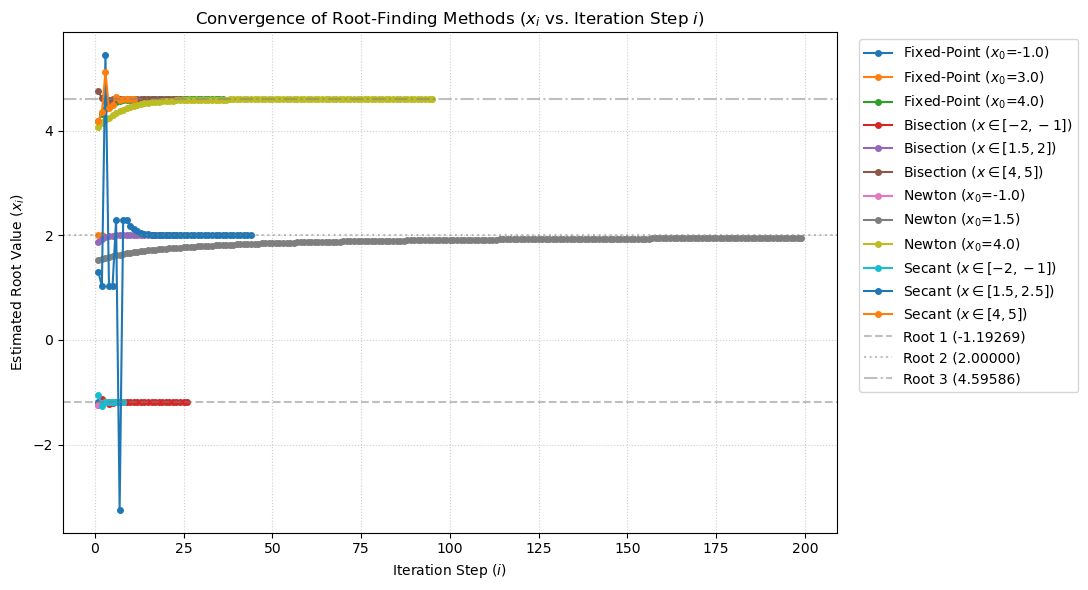

In [177]:
import sys
import io
import matplotlib.pyplot as plt

#helper function - runs existing function and reads its printed output
def run_and_capture(func, *args, **kwargs):
    buffer = io.StringIO()
    old_stdout = sys.stdout
    sys.stdout = buffer  # Redirect printed output
    
    func(*args, **kwargs)  # Calls your existing function directly!
    
    sys.stdout = old_stdout  # Restore normal printing
    
    # Extract the second column (x_i value) from each printed row
    output = buffer.getvalue().strip().split('\n')
    history = []
    for line in output:
        parts = line.split()
        if len(parts) >= 2:
            history.append(float(parts[1]))  # Column index 1 is x_i
            
    return history

#listing existing functions and parameters here
runs = [("Fixed-Point ($x_0$=-1.0)", run_and_capture(fixedpoint, g1, -1.0)),
        ("Fixed-Point ($x_0$=3.0)", run_and_capture(fixedpoint, g2, 3.0)),
        ("Fixed-Point ($x_0$=4.0)", run_and_capture(fixedpoint, g3, 4.0)),
    
        ("Bisection ($x\in[-2, -1]$)", run_and_capture(bisection_method, f, -2.0, -1.0)),
        ("Bisection ($x\in[1.5, 2]$)", run_and_capture(bisection_method, f, 1.5, 2.0)),
        ("Bisection ($x\in[4, 5]$)", run_and_capture(bisection_method, f, 4.0, 5.0)),
    
        ("Newton ($x_0$=-1.0)", run_and_capture(newton, f, df, -1.0)),
        ("Newton ($x_0$=1.5)", run_and_capture(newton, f, df, 1.5)),
        ("Newton ($x_0$=4.0)", run_and_capture(newton, f, df, 4.0)),
    
        ("Secant ($x\in[-2, -1]$)", run_and_capture(secant, f, -2.0, -1.0)),
        ("Secant ($x\in[1.5, 2.5]$)", run_and_capture(secant, f, 1.5, 2.5)),
        ("Secant ($x\in[4, 5]$)", run_and_capture(secant, f, 4.0, 5.0)), ]

plt.figure(figsize=(11, 6))

for label, history in runs:
    steps = range(1, len(history) + 1)
    plt.plot(steps, history, 'o-', label=label, linewidth=1.5, markersize=4)

plt.axhline(-1.19268576, color='gray', linestyle='--', alpha=0.5, label='Root 1 (-1.19269)')
plt.axhline(2.0, color='gray', linestyle=':', alpha=0.5, label='Root 2 (2.00000)')
plt.axhline(4.59586349, color='gray', linestyle='-.', alpha=0.5, label='Root 3 (4.59586)')

plt.title('Convergence of Root-Finding Methods ($x_i$ vs. Iteration Step $i$)')
plt.xlabel('Iteration Step ($i$)')
plt.ylabel('Estimated Root Value ($x_i$)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

#### Problem 1 code summary

The structure of the code is derived from Gezerlis code itself, edited these codes respectively depending on the methods. For fixed-point method, I turned the given function $f(x)$ into $g_i(x)$ where $i=1,2,3$, and for the other methods, the fule $f(x)$ 

---